# 06: Choosing the Regularization Parameter

## Learning objectives
- Understand why the choice of regularization parameter λ matters.
- Use the **L-curve** method to choose λ by finding the corner of the curve.
- Use **ABIC** (Akaike Bayesian Information Criterion) to choose λ statistically.
- Compare the two approaches on our synthetic fault-slip problem.

## Background: the regularization parameter problem

In notebook 05 we solved the regularized least-squares problem:

$$
\|Gs - d\|^2 + \lambda^2 \|Ls\|^2
$$

But we simply *guessed* a value of λ = 0.001. In practice, the choice of λ is critical:

- **Too small (λ → 0)** — the solution is driven almost entirely by data fit. Because real data contain noise, the inversion tends to fit the noise as well as the signal, producing a rough, unrealistic slip distribution.
- **Too large (λ → ∞)** — the regularization term dominates. The solution is forced to be very smooth (or small), but it no longer fits the observations well.

We need a systematic, objective way to choose λ. Two common approaches are:

1. **The L-curve method** — a graphical method. We plot data misfit against model roughness for many values of λ. The plot forms an L-shape; the "corner" of the L gives a good trade-off.
2. **ABIC (Akaike Bayesian Information Criterion)** — a statistical method. We treat the regularization as a Bayesian prior and find the λ that best explains the data in a probabilistic sense.

Both methods are *automatic* — they give us a specific recommended value of λ rather than requiring trial and error.

In [22]:
# ============================================================
# SETUP: Import libraries
# ============================================================

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import okada_utils

# Default figure settings
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

# Fix random seed so results are reproducible
rng = np.random.default_rng(8)

print("Libraries loaded.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded.


In [23]:
# ============================================================
# REBUILD THE FAULT MODEL (same as notebook 05)
# ============================================================
# We reproduce the synthetic problem exactly so this notebook
# can be run independently.

# --- Fault geometry parameters ---
fault_x0     = 0.0      # fault center, easting (m)
fault_y0     = 0.0      # fault center, northing (m)
fault_z0     = 8.0e3    # fault top depth (m)
fault_strike = 315.0    # strike angle (degrees)
fault_dip    = 20.0     # dip angle (degrees)
fault_L      = 40.0e3   # fault length along strike (m)
fault_W      = 16.0e3   # fault width down-dip (m)
nL           = 12       # number of patches along strike
nW           = 8        # number of patches down-dip

# Build the grid of rectangular fault patches
patches = okada_utils.build_patch_grid(
    fault_x0, fault_y0, fault_z0,
    fault_strike, fault_dip,
    fault_L, fault_W,
    nL, nW
)
npatch = len(patches)
print("Number of fault patches:", npatch)

# --- Define observation (GPS/InSAR) locations ---
e_axis = np.linspace(-38000, 38000, 4)    # easting values (m)
n_axis = np.linspace(-28000, 28000, 5)   # northing values (m)
E, N   = np.meshgrid(e_axis, n_axis)     # 2D grid
obs_e  = E.ravel()                        # flatten to 1D arrays
obs_n  = N.ravel()
nobs   = obs_e.size
print("Number of observation points:", nobs)

# --- Build Green's functions ---
# GE[i, j] = predicted east displacement at obs i due to unit slip on patch j
# Similarly for GN (north) and GU (up/vertical)
GE, GN, GU = okada_utils.build_component_greens(obs_e, obs_n, patches, rake_deg=90.0)

# Stack all three components into a single Green's function matrix
G = np.vstack([GE, GN, GU])
print("Shape of G:", G.shape, "  (rows = 3*nobs, cols = npatch)")

# --- Create a synthetic 'true' slip model (Gaussian bump) ---
s_true = np.zeros(npatch)
for k in range(npatch):
    p = patches[k]
    i = p['i']    # along-strike patch index
    j = p['j']    # down-dip patch index
    # Gaussian shape centered at (i=5, j=3)
    s_true[k] = 1.2 * np.exp(-((i - 5.0)**2) / 4.0 - ((j - 3.0)**2) / 1.2)

# --- Generate synthetic observations = G * s_true + noise ---
noise_level = 0.001
uE_obs = GE @ s_true + rng.normal(0.0, noise_level * np.max(np.abs(GE @ s_true)), size=nobs)
uN_obs = GN @ s_true + rng.normal(0.0, noise_level * np.max(np.abs(GN @ s_true)), size=nobs)
uU_obs = GU @ s_true + rng.normal(0.0, noise_level * np.max(np.abs(GU @ s_true)), size=nobs)

# Combine all observations into a single data vector d
d      = np.concatenate([uE_obs, uN_obs, uU_obs])
N_data = len(d)    # total number of observations
print("Total number of data values:", N_data)

# --- Build the 2D Laplacian smoothing matrix L ---
# L penalizes patch-to-patch variations in slip
L = okada_utils.build_laplacian_2d_simple(nL, nW)
print("Shape of L:", L.shape)

Number of fault patches: 96
Number of observation points: 20
Shape of G: (60, 96)   (rows = 3*nobs, cols = npatch)
Total number of data values: 60
Shape of L: (96, 96)


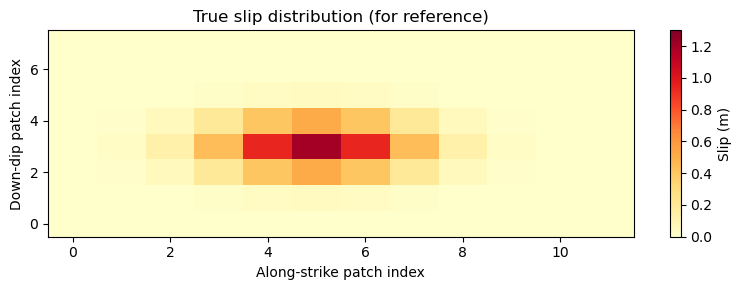

In [24]:
# ============================================================
# HELPER FUNCTION: display slip as a 2D image
# ============================================================
# This reshapes the 1D slip vector (one entry per patch) into
# a 2D grid (nW rows x nL columns) and uses imshow to display.

def show_slip(slip_vector, title, vmin=None, vmax=None):
    # Reshape the flat 1D array into a 2D grid
    slip_grid = slip_vector.reshape(nW, nL)

    fig, ax = plt.subplots(figsize=(8, 3))
    img = ax.imshow(
        slip_grid,
        origin='lower',     # row 0 at bottom (shallow patches)
        aspect='auto',
        cmap='YlOrRd',
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(img, ax=ax, label='Slip (m)')
    ax.set_xlabel('Along-strike patch index')
    ax.set_ylabel('Down-dip patch index')
    ax.set_title(title)
    ax.grid(visible=False)
    plt.tight_layout()
    plt.show()

# Display the true slip for reference
show_slip(s_true, 'True slip distribution (for reference)', vmin=0, vmax=1.3)

---
## Part 1: The L-curve Method

### What is the L-curve?

The idea is straightforward:

1. Solve the regularized problem for many different values of λ.
2. For each solution, record two numbers:
   - **Data misfit** `||Gs - d||` — how well the model fits the observations.
   - **Roughness** `||Ls||` — how irregular (rough) the model is.
3. Plot roughness on the x-axis and misfit on the y-axis (both on log scales).

The resulting curve looks like the letter **L**:
- On the **top-left** branch: small λ → the model fits the data very well, but is very rough.
- On the **bottom-right** branch: large λ → the model is smooth, but fits the data poorly.
- At the **corner**: a good balance between fit and smoothness.

The optimal λ is at the corner — the point of maximum curvature of the L-curve.

In [62]:
# ============================================================
# STEP 1: Compute the L-curve
# ============================================================
# We solve the regularized problem for 100 values of lambda,
# logarithmically spaced from 10^-6 to 10^-2.
# Logarithmic spacing is important because we are exploring
# many orders of magnitude.

lambda_values = np.logspace(-6, -2, 100)

# Create empty arrays to store the results for each lambda
misfit_norms   = np.zeros(len(lambda_values))
roughness_norms = np.zeros(len(lambda_values))

print("Computing L-curve (solving", len(lambda_values), "regularized systems)...")

for i in range(len(lambda_values)):

    lam = lambda_values[i]    # current value of lambda

    # Build the augmented (stacked) least-squares system:
    #
    #   [ G       ] s  =  [ d ]
    #   [ lam * L ]        [ 0 ]
    #
    # Minimizing the 2-norm of the residual of this system is exactly
    # the same as minimizing ||Gs - d||^2 + lam^2 * ||Ls||^2.
    G_aug = np.vstack([G, lam * L])
    d_aug = np.concatenate([d, np.zeros(L.shape[0])])

    # Solve with least squares
    # result[0] is the solution vector s_reg
    result = np.linalg.lstsq(G_aug, d_aug, rcond=None)
    s_reg  = result[0]

    # --- Compute data misfit: ||G*s - d|| ---
    # This measures how well our model explains the observations.
    d_predicted   = G @ s_reg
    misfit_vector = d - d_predicted
    misfit_norm   = np.sqrt(np.sum(misfit_vector**2))
    misfit_norms[i] = misfit_norm

    # --- Compute roughness: ||L*s|| ---
    # This measures how "rough" or spatially variable the slip is.
    roughness_vector  = L @ s_reg
    roughness_norm    = np.sqrt(np.sum(roughness_vector**2))
    roughness_norms[i] = roughness_norm

print("Done.")

Computing L-curve (solving 100 regularized systems)...
Done.


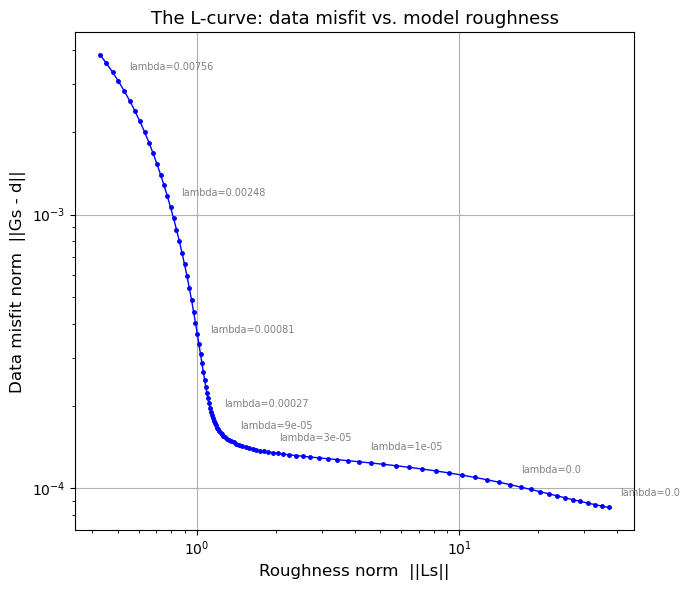

In [63]:
# ============================================================
# STEP 2: Plot the L-curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

# Plot the L-curve itself
ax.plot(roughness_norms, misfit_norms, 'b.-', linewidth=1, markersize=5)

# Annotate a few representative lambda values so we can see
# where each part of the curve comes from.
# We label every 12th point to avoid overcrowding.
for i in range(0, len(lambda_values), 12):
    ax.annotate(
        'lambda=' + str(round(lambda_values[i], 5)),
        xy=(roughness_norms[i], misfit_norms[i]),
        xytext=(roughness_norms[i] * 1.1, misfit_norms[i] * 1.1),
        fontsize=7,
        color='gray'
    )

ax.set_xlabel('Roughness norm  ||Ls||', fontsize=12)
ax.set_ylabel('Data misfit norm  ||Gs - d||', fontsize=12)
ax.set_title('The L-curve: data misfit vs. model roughness', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Notice the L-shape:
# - Top-left: small lambda, small misfit, large roughness
# - Bottom-right: large lambda, large misfit, small roughness
# - The "corner" is where we want to be.

### Finding the corner: curvature of the L-curve

Visually, the corner is obvious. But to automate the choice of λ, we compute the **curvature** of the L-curve at each point and pick the λ where curvature is maximum.

For a curve described by two coordinates that both depend on a parameter *t*, the curvature formula is:

$$
\kappa = \frac{x'\, y'' - y'\, x''}{\left(x'^2 + y'^2\right)^{3/2}}
$$

where primes denote derivatives with respect to *t*.

Here we use:
- $t = \log(\lambda)$ (the curve parameter)
- $x(t) = \log(\|Ls\|)$ (log roughness)
- $y(t) = \log(\|Gs - d\|)$ (log misfit)

We estimate derivatives numerically using `np.gradient`, which computes central finite differences.

In [49]:
# ============================================================
# STEP 3: Compute the curvature of the L-curve
# ============================================================

# Work in log-log space (that is where the L-shape is visible)
log_roughness = np.log(roughness_norms)
log_misfit    = np.log(misfit_norms)

# Curve parameter: t = log(lambda)
t = np.log(lambda_values)

# --- First derivatives (using central finite differences) ---
# dx_dt = d(log roughness) / d(log lambda)
# dy_dt = d(log misfit) / d(log lambda)
dx_dt = np.gradient(log_roughness, t)
dy_dt = np.gradient(log_misfit,    t)

# --- Second derivatives ---
d2x_dt2 = np.gradient(dx_dt, t)
d2y_dt2 = np.gradient(dy_dt, t)

# --- Curvature formula for a parametric curve (x(t), y(t)) ---
# kappa = (x' * y'' - y' * x'') / (x'^2 + y'^2)^(3/2)
numerator   = dx_dt * d2y_dt2 - dy_dt * d2x_dt2
denominator = (dx_dt**2 + dy_dt**2)**1.5
curvature   = numerator / denominator

# The optimal lambda is where curvature is most negative (most curved = the corner)
best_idx_lcurve    = np.argmin(curvature)
best_lambda_lcurve = lambda_values[best_idx_lcurve]

print("Optimal lambda from L-curve curvature:", round(best_lambda_lcurve, 6))
print("  (corresponds to index", best_idx_lcurve, "out of", len(lambda_values), ")")

Optimal lambda from L-curve curvature: 0.000138
  (corresponds to index 53 out of 100 )


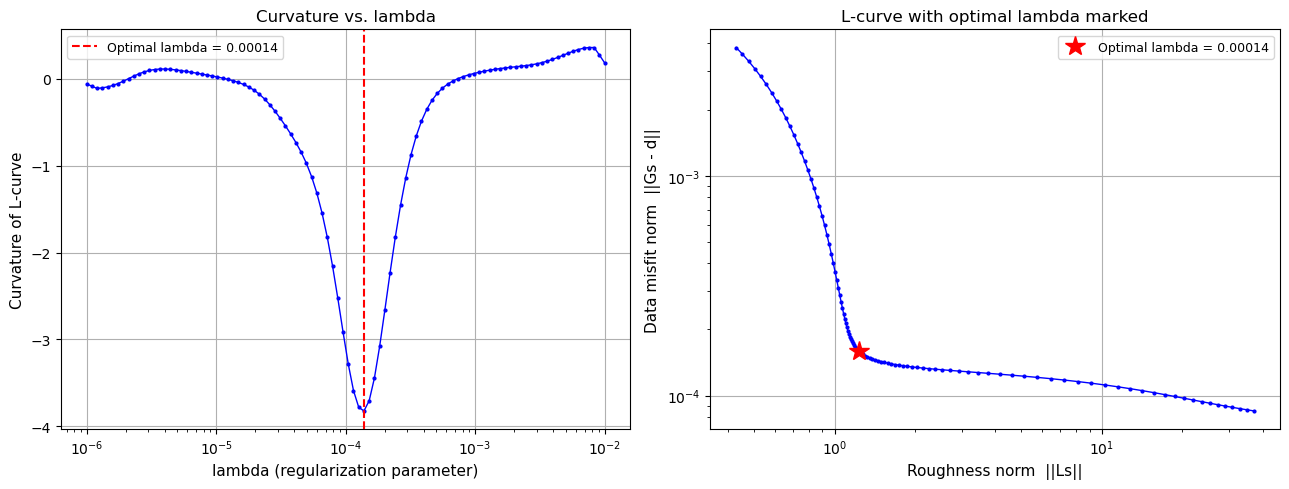

In [50]:
# ============================================================
# STEP 4: Plot curvature vs lambda, and mark the optimal point
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: curvature as a function of lambda ---
ax = axes[0]
ax.plot(lambda_values, curvature, 'b.-', linewidth=1, markersize=4)
ax.axvline(
    best_lambda_lcurve,
    color='red', linestyle='--',
    label='Optimal lambda = ' + str(round(best_lambda_lcurve, 5))
)
ax.set_xlabel('lambda (regularization parameter)', fontsize=11)
ax.set_ylabel('Curvature of L-curve', fontsize=11)
ax.set_title('Curvature vs. lambda', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=9)

# --- Right panel: L-curve with optimal point marked ---
ax = axes[1]
ax.plot(roughness_norms, misfit_norms, 'b.-', linewidth=1, markersize=4)
ax.plot(
    roughness_norms[best_idx_lcurve],
    misfit_norms[best_idx_lcurve],
    'r*', markersize=15,
    label='Optimal lambda = ' + str(round(best_lambda_lcurve, 5))
)
ax.set_xlabel('Roughness norm  ||Ls||', fontsize=11)
ax.set_ylabel('Data misfit norm  ||Gs - d||', fontsize=11)
ax.set_title('L-curve with optimal lambda marked', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

L-curve optimal lambda : 0.000138
Data RMSE              : 2.1e-05
RMSE vs true slip      : 0.104053


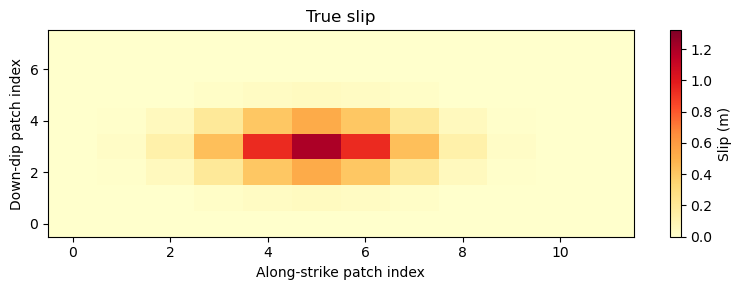

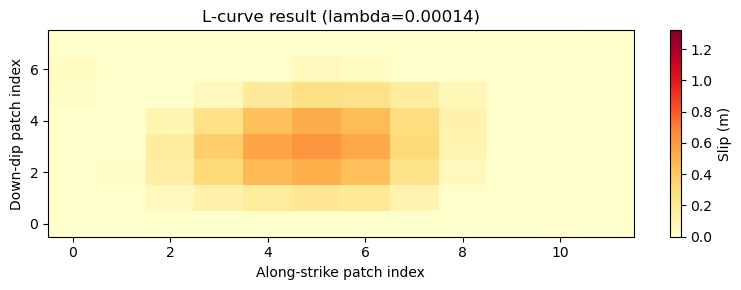

In [51]:
# ============================================================
# STEP 5: Solve the inversion with the L-curve optimal lambda
# ============================================================

# Build and solve the regularized system at the optimal lambda
G_lcurve = np.vstack([G, best_lambda_lcurve * L])
d_lcurve = np.concatenate([d, np.zeros(L.shape[0])])
result   = np.linalg.lstsq(G_lcurve, d_lcurve, rcond=None)
s_lcurve = result[0]    # the optimal slip model

# Compute data fit quality (RMSE)
d_predicted  = G @ s_lcurve
residuals    = d - d_predicted
rmse_lcurve  = np.sqrt(np.mean(residuals**2))

# Compute how close we are to the true slip (since we know it)
error_vs_true = s_lcurve - s_true
rmse_vs_true  = np.sqrt(np.mean(error_vs_true**2))

print("L-curve optimal lambda :", round(best_lambda_lcurve, 6))
print("Data RMSE              :", round(rmse_lcurve, 6))
print("RMSE vs true slip      :", round(rmse_vs_true, 6))

# Display the resulting slip model
vmax_plot = float(np.max(s_true)) * 1.1
show_slip(s_true,    'True slip',                              vmin=0, vmax=vmax_plot)
show_slip(s_lcurve,  'L-curve result (lambda=' + str(round(best_lambda_lcurve, 5)) + ')', vmin=0, vmax=vmax_plot)

---
## Part 2: ABIC — Akaike Bayesian Information Criterion

### What is ABIC?

ABIC was introduced by Akaike (1980) and has been widely used in Japanese geodetic inversions (Yabuki & Matsu'ura 1992). It provides a statistical framework for choosing λ.

**The key idea:**

We interpret the regularization term as a *Bayesian prior* on the slip:
- The data fit term `||Gs - d||²` comes from assuming data errors are Gaussian.
- The smoothing term `λ² ||Ls||²` comes from assuming the slip obeys a Gaussian smoothness prior.

If we treat λ² (call it α) as an unknown parameter, we can ask: *for which α does the data best support the model, accounting for both the fit and the prior?* This is answered by maximizing the **marginal likelihood** — the probability of observing the data d after integrating out the unknown slip s.

Minimizing ABIC is equivalent to maximizing the marginal likelihood.

### The ABIC formula

After integrating out the slip model s, the ABIC simplifies to (Yabuki & Matsu'ura 1992):

$$
\text{ABIC}(\alpha) = (N - p + q)\,\ln S(\alpha)
                    + \ln\!\det\!\left(G^\top G + \alpha\, L^\top L\right)
                    - q\,\ln \alpha
$$

where:
- $\alpha = \lambda^2$ (the regularization strength)
- $N$ = number of data observations
- $p$ = number of model parameters (fault patches)
- $q$ = rank of the smoothing matrix $L$
- $S(\alpha) = \|Gs_\alpha - d\|^2 + \alpha\,\|Ls_\alpha\|^2$ (total objective at optimum)
- $\det(G^\top G + \alpha L^\top L)$ is the determinant of the Hessian matrix

We **minimize ABIC over α** (equivalently, over λ).

**Intuition behind the three terms:**
1. $(N - p + q)\ln S$ — penalizes large total misfit (worse fit → larger ABIC).
2. $\ln\det(H)$ — accounts for how many "effective parameters" the model uses; more complex models have larger Hessians.
3. $-q\ln\alpha$ — penalizes *too much* regularization (over-smoothing also hurts the criterion).

In [52]:
# ============================================================
# ABIC SETUP: compute key dimensions
# ============================================================

# N: total number of data observations
N_data = len(d)
print("N (number of data)          :", N_data)

# p: number of model parameters (one per fault patch)
p = npatch
print("p (number of model params)  :", p)

# q: rank of the smoothing matrix L
# For the Laplacian, this is usually close to (but not equal to) L.shape[0]
# because the Laplacian has a small null space.
q = int(np.linalg.matrix_rank(L))
print("q (rank of L)               :", q)
print("  (rows of L for reference  :", L.shape[0], ")")

# Precompute G^T * G and L^T * L once
# These do not depend on lambda, so we only compute them once
# to avoid repeating this expensive operation inside the loop.
GtG = G.T @ G    # shape: (npatch, npatch)
LtL = L.T @ L    # shape: (npatch, npatch)
print("Shapes of GtG and LtL:", GtG.shape, LtL.shape)

N (number of data)          : 60
p (number of model params)  : 96
q (rank of L)               : 95
  (rows of L for reference  : 96 )
Shapes of GtG and LtL: (96, 96) (96, 96)


In [53]:
# ============================================================
# COMPUTE ABIC FOR EACH LAMBDA VALUE
# ============================================================
# We reuse the same lambda_values array from the L-curve section.

abic_values = np.zeros(len(lambda_values))

print("Computing ABIC for", len(lambda_values), "values of lambda...")

for i in range(len(lambda_values)):

    lam   = lambda_values[i]
    alpha = lam**2    # alpha = lambda^2 is the Bayesian prior precision

    # ---- Step A: Solve the regularized inverse problem ----
    G_aug  = np.vstack([G, lam * L])
    d_aug  = np.concatenate([d, np.zeros(L.shape[0])])
    result = np.linalg.lstsq(G_aug, d_aug, rcond=None)
    s_reg  = result[0]

    # ---- Step B: Compute total objective S(alpha) ----
    # S = ||G*s - d||^2 + alpha * ||L*s||^2
    d_pred         = G @ s_reg
    data_misfit_sq = np.sum((d - d_pred)**2)     # ||G*s - d||^2

    roughness_vec  = L @ s_reg
    roughness_sq   = np.sum(roughness_vec**2)    # ||L*s||^2

    S = data_misfit_sq + alpha * roughness_sq

    # ---- Step C: Compute log-determinant of the Hessian ----
    # Hessian H = G^T G + alpha * L^T L
    H = GtG + alpha * LtL

    # np.linalg.slogdet computes the sign and *log* of the determinant.
    # Using the log avoids numerical overflow/underflow for large matrices.
    # We only need logdet_H (the second return value).
    sign, logdet_H = np.linalg.slogdet(H)

    # ---- Step D: Compute ABIC ----
    # ABIC = (N - p + q) * ln(S) + ln|det(H)| - q * ln(alpha)
    #
    # Guard against S <= 0 (should not happen with valid data, but just in case)
    if S > 0 and sign > 0:
        abic = (N_data - p + q) * np.log(S) + logdet_H - q * np.log(alpha)
    else:
        abic = np.inf    # mark invalid values

    abic_values[i] = abic

print("Done.")

Computing ABIC for 100 values of lambda...
Done.


Optimal lambda from ABIC: 9.5e-05


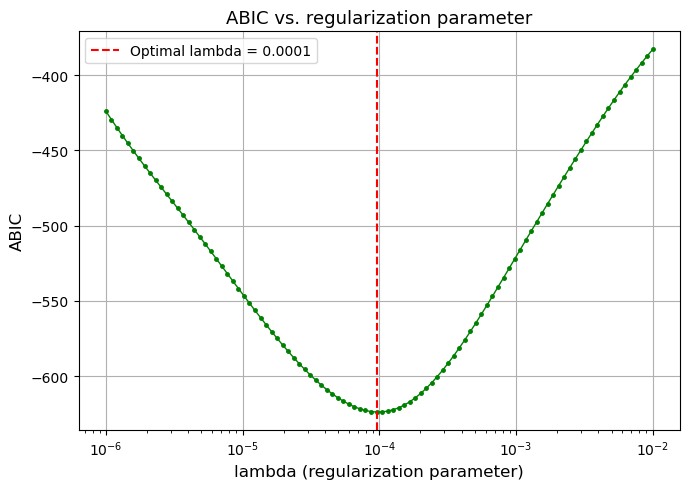

In [54]:
# ============================================================
# PLOT ABIC VS LAMBDA
# ============================================================

# Find the lambda that gives the minimum ABIC
best_idx_abic    = np.argmin(abic_values)
best_lambda_abic = lambda_values[best_idx_abic]

print("Optimal lambda from ABIC:", round(best_lambda_abic, 6))

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(lambda_values, abic_values, 'g.-', linewidth=1, markersize=5)
ax.axvline(
    best_lambda_abic,
    color='red', linestyle='--',
    label='Optimal lambda = ' + str(round(best_lambda_abic, 5))
)
ax.set_xlabel('lambda (regularization parameter)', fontsize=12)
ax.set_ylabel('ABIC', fontsize=12)
ax.set_title('ABIC vs. regularization parameter', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Note: the minimum of the ABIC curve gives the optimal lambda.
# The curve should have a clear minimum; a flat bottom suggests the
# data do not strongly constrain lambda (usually means low signal-to-noise).

ABIC optimal lambda    : 9.5e-05
Data RMSE              : 2e-05
RMSE vs true slip      : 0.102733


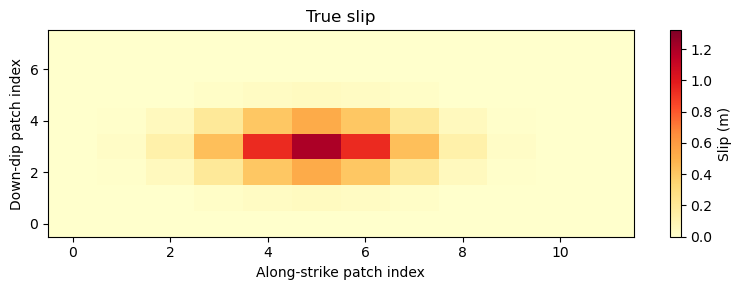

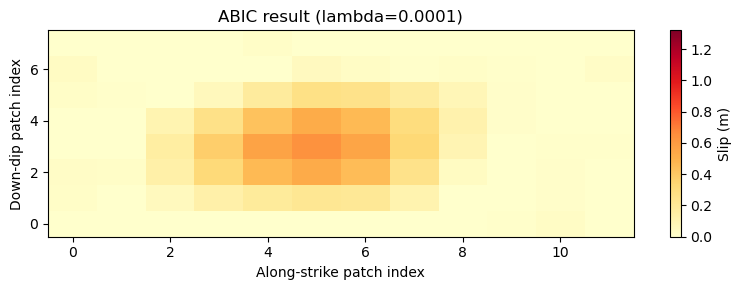

In [55]:
# ============================================================
# SOLVE THE INVERSION WITH THE ABIC OPTIMAL LAMBDA
# ============================================================

# Build and solve the system at the ABIC-optimal lambda
G_abic = np.vstack([G, best_lambda_abic * L])
d_abic = np.concatenate([d, np.zeros(L.shape[0])])
result = np.linalg.lstsq(G_abic, d_abic, rcond=None)
s_abic = result[0]

# Data fit quality
d_pred_abic = G @ s_abic
residuals   = d - d_pred_abic
rmse_abic   = np.sqrt(np.mean(residuals**2))

# Error vs true slip
error_abic     = s_abic - s_true
rmse_vs_true_abic = np.sqrt(np.mean(error_abic**2))

print("ABIC optimal lambda    :", round(best_lambda_abic, 6))
print("Data RMSE              :", round(rmse_abic, 6))
print("RMSE vs true slip      :", round(rmse_vs_true_abic, 6))

# Display the ABIC result alongside the true slip
vmax_plot = float(np.max(s_true)) * 1.1
show_slip(s_true,   'True slip',                             vmin=0, vmax=vmax_plot)
show_slip(s_abic,   'ABIC result (lambda=' + str(round(best_lambda_abic, 5)) + ')',  vmin=0, vmax=vmax_plot)

---
## Part 3: Comparison of the Two Methods

Now let us compare all four models side by side:
1. A hand-chosen reference solution (λ = 0.001 from notebook 05)
2. The L-curve optimal solution
3. The ABIC optimal solution
4. The true slip (which we know because this is synthetic data)

In a real application you would not know the true slip, but you *can* check how close the two automatic methods agree — if they choose similar λ values, that is reassuring.

In [56]:
# ============================================================
# COMPARISON: reference vs L-curve vs ABIC
# ============================================================

# --- Reference solution (manually chosen lambda from notebook 05) ---
lam_reference = 0.001
G_ref  = np.vstack([G, lam_reference * L])
d_ref  = np.concatenate([d, np.zeros(L.shape[0])])
s_ref  = np.linalg.lstsq(G_ref, d_ref, rcond=None)[0]

# --- Compute statistics for each model ---
# We measure two things:
#   (a) data RMSE: how well does the model fit the observations?
#   (b) slip RMSE: how close is the model to the true slip?

def data_rmse(s):
    # Compute RMSE between predicted data and observed data
    d_pred = G @ s
    return np.sqrt(np.mean((d - d_pred)**2))

def slip_rmse(s):
    # Compute RMSE between recovered slip and true slip
    return np.sqrt(np.mean((s - s_true)**2))

print("Method            | Lambda     | Data RMSE | Slip RMSE")
print("-" * 60)
print("Reference (0.001) |", round(lam_reference,        5), "  |", round(data_rmse(s_ref),    5), " |", round(slip_rmse(s_ref),    5))
print("L-curve           |", round(best_lambda_lcurve,   5), "  |", round(data_rmse(s_lcurve), 5), " |", round(slip_rmse(s_lcurve), 5))
print("ABIC              |", round(best_lambda_abic,     5), "  |", round(data_rmse(s_abic),   5), " |", round(slip_rmse(s_abic),   5))

Method            | Lambda     | Data RMSE | Slip RMSE
------------------------------------------------------------
Reference (0.001) | 0.001   | 5e-05  | 0.11611
L-curve           | 0.00014   | 2e-05  | 0.10405
ABIC              | 0.0001   | 2e-05  | 0.10273


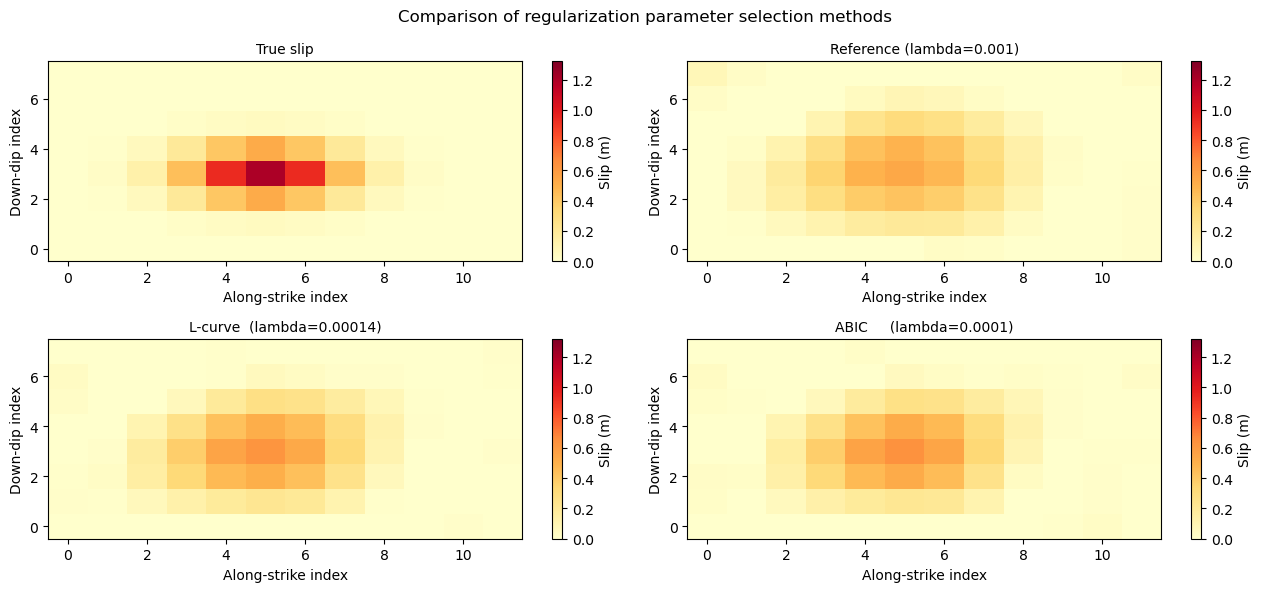

In [57]:
# ============================================================
# SIDE-BY-SIDE SLIP COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 6))

vmax_plot = float(np.max(s_true)) * 1.1

# --- List of (axis, slip, title) to plot ---
# We use a plain loop so the structure is easy to follow.
all_slips  = [s_true, s_ref, s_lcurve, s_abic]
all_titles = [
    'True slip',
    'Reference (lambda=0.001)',
    'L-curve  (lambda=' + str(round(best_lambda_lcurve, 5)) + ')',
    'ABIC     (lambda=' + str(round(best_lambda_abic,   5)) + ')'
]
all_axes = axes.ravel()    # flatten 2x2 grid to a 1D list

for k in range(4):
    ax    = all_axes[k]
    slip  = all_slips[k]
    title = all_titles[k]

    # Reshape slip to 2D grid and display
    slip_grid = slip.reshape(nW, nL)
    img = ax.imshow(
        slip_grid,
        origin='lower',
        aspect='auto',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax_plot
    )
    plt.colorbar(img, ax=ax, label='Slip (m)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Along-strike index')
    ax.set_ylabel('Down-dip index')
    ax.grid(visible=False)

plt.suptitle('Comparison of regularization parameter selection methods', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary

### What we did
1. Solved the regularized slip inversion for 60 values of λ spanning several orders of magnitude.
2. **L-curve method**: plotted data misfit vs. roughness in log-log space. Found the corner (maximum curvature) to select λ automatically.
3. **ABIC method**: computed a statistical criterion (marginal log-likelihood) for each λ and found the minimum.

### Key takeaways

| Feature | L-curve | ABIC |
|---|---|---|
| Basis | Geometric / graphical | Statistical / Bayesian |
| Requires noise level? | No | No (marginalizes over σ²) |
| Computationally | Same cost (already solved) | Small extra cost (slogdet) |
| Common weakness | Corner can be ambiguous if the curve has no sharp bend | Assumes Gaussian errors and prior |

- Both methods aim to balance data fit against model complexity, but they approach the problem differently.
- In practice, it is good to apply *both* methods and check whether they agree. When they give similar λ values, you can be more confident in the result.
- Neither method is guaranteed to be "correct" — they are heuristics that work well when the assumed statistical model is a reasonable approximation.

### What to try next
- Change the noise level (`noise_level`) in the setup cell and re-run. How do the optimal λ values change?
- Try using ridge regularization (`L = np.eye(npatch)`) instead of the Laplacian. Does the L-curve still have a clear corner?
- In a real problem, you would not know `s_true`. Can you still judge the quality of the result?